In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')

print('Shape:', df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'Jumlah': missing, 'Persen (%)': missing_pct.round(1)})
missing_df = missing_df[missing_df['Jumlah'] > 0].sort_values('Persen (%)', ascending=False)
print(missing_df)

              Jumlah  Persen (%)
PoolQC          1453        99.5
MiscFeature     1406        96.3
Alley           1369        93.8
Fence           1179        80.8
MasVnrType       872        59.7
FireplaceQu      690        47.3
LotFrontage      259        17.7
GarageType        81         5.5
GarageYrBlt       81         5.5
GarageFinish      81         5.5
GarageQual        81         5.5
GarageCond        81         5.5
BsmtExposure      38         2.6
BsmtFinType2      38         2.6
BsmtQual          37         2.5
BsmtCond          37         2.5
BsmtFinType1      37         2.5
MasVnrArea         8         0.5
Electrical         1         0.1


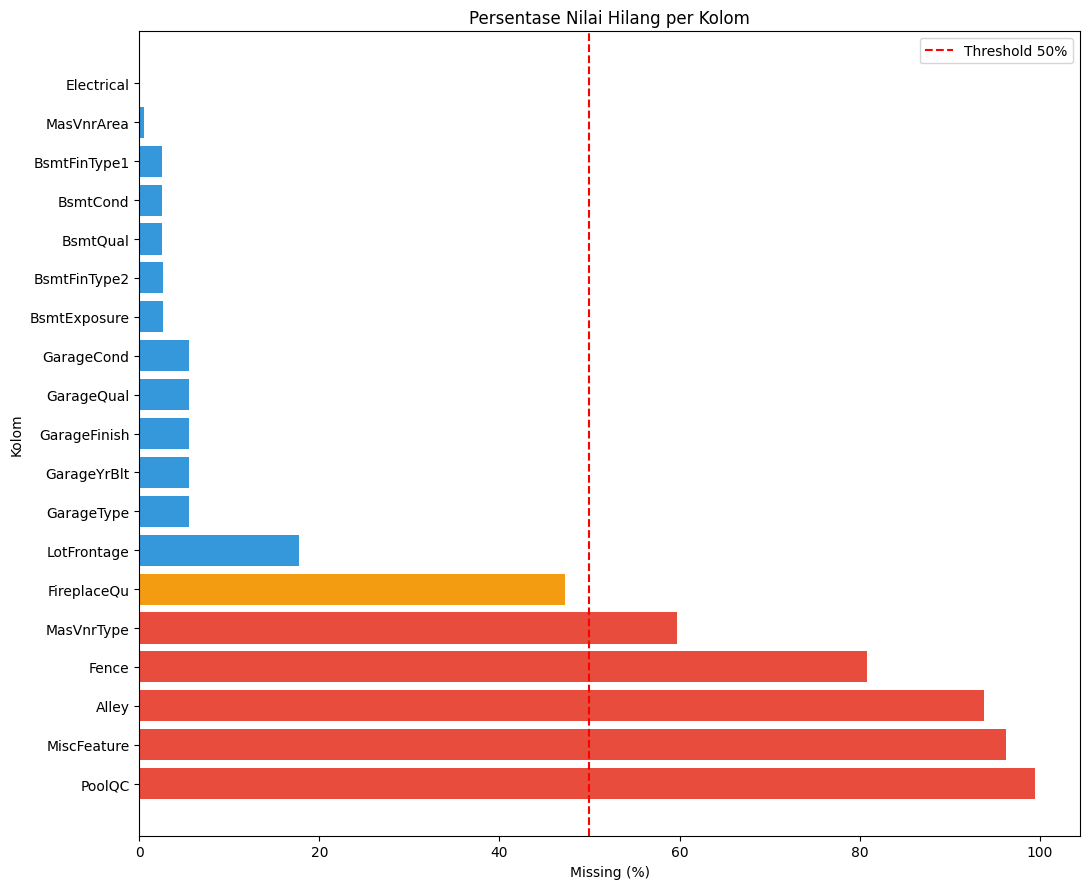

In [4]:
plt.figure(figsize=(11, 9))

colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#3498db'
          for v in missing_df['Persen (%)']]
plt.barh(missing_df.index, missing_df['Persen (%)'], color=colors)
plt.axvline(50, color='red', linestyle='--', label='Threshold 50%')
plt.xlabel('Missing (%)')
plt.ylabel('Kolom')
plt.title('Persentase Nilai Hilang per Kolom')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
threshold = 0.5
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print('Kolom yang dihapus:', cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)
print('Shape setelah drop:', df.shape)

Kolom yang dihapus: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
Shape setelah drop: (1460, 76)


In [6]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns
                
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print('Total nilai hilang setelah imputasi:', df.isnull().sum().sum())

Total nilai hilang setelah imputasi: 0


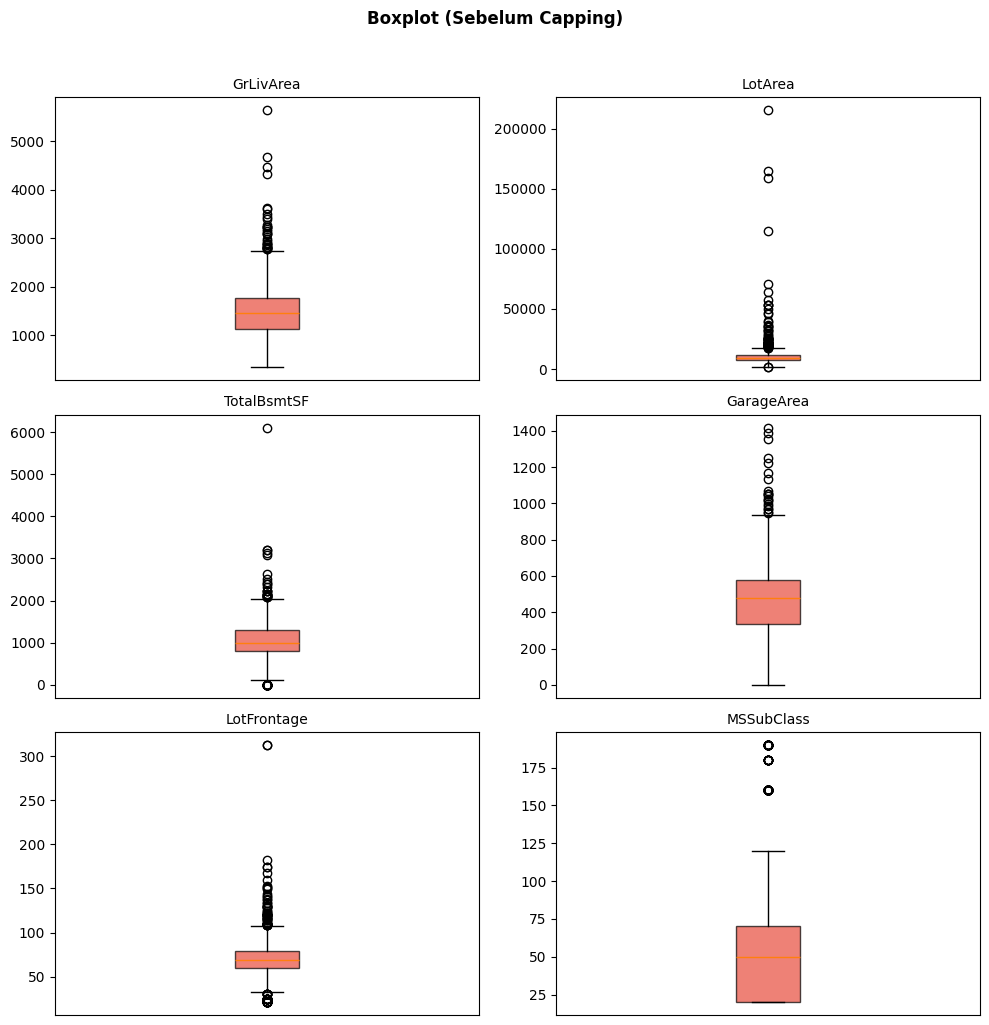

In [7]:
sample_cols = ['GrLivArea','LotArea','TotalBsmtSF','GarageArea','LotFrontage','MSSubClass',]

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes_flat = axes.flatten()
for i, col in enumerate(sample_cols):
    axes_flat[i].boxplot(df[col].dropna(),patch_artist=True,
        boxprops=dict(facecolor='#e74c3c', alpha=0.7),)
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_xticks([])

plt.suptitle(
    'Boxplot (Sebelum Capping)', fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [8]:
numeric_features = df.select_dtypes(include='number').columns.drop(['Id', 'SalePrice'])

outlier_info = []
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info.append({'Kolom': col, 'Jumlah Outlier': n})

outlier_df = pd.DataFrame(outlier_info).sort_values('Jumlah Outlier', ascending=False)
print(outlier_df[outlier_df['Jumlah Outlier'] > 0].head(10).to_string(index=False))

        Kolom  Jumlah Outlier
EnclosedPorch             208
   BsmtFinSF2             167
  OverallCond             125
  ScreenPorch             116
  LotFrontage             106
   MSSubClass             103
   MasVnrArea              98
 BsmtHalfBath              82
  OpenPorchSF              77
      LotArea              69


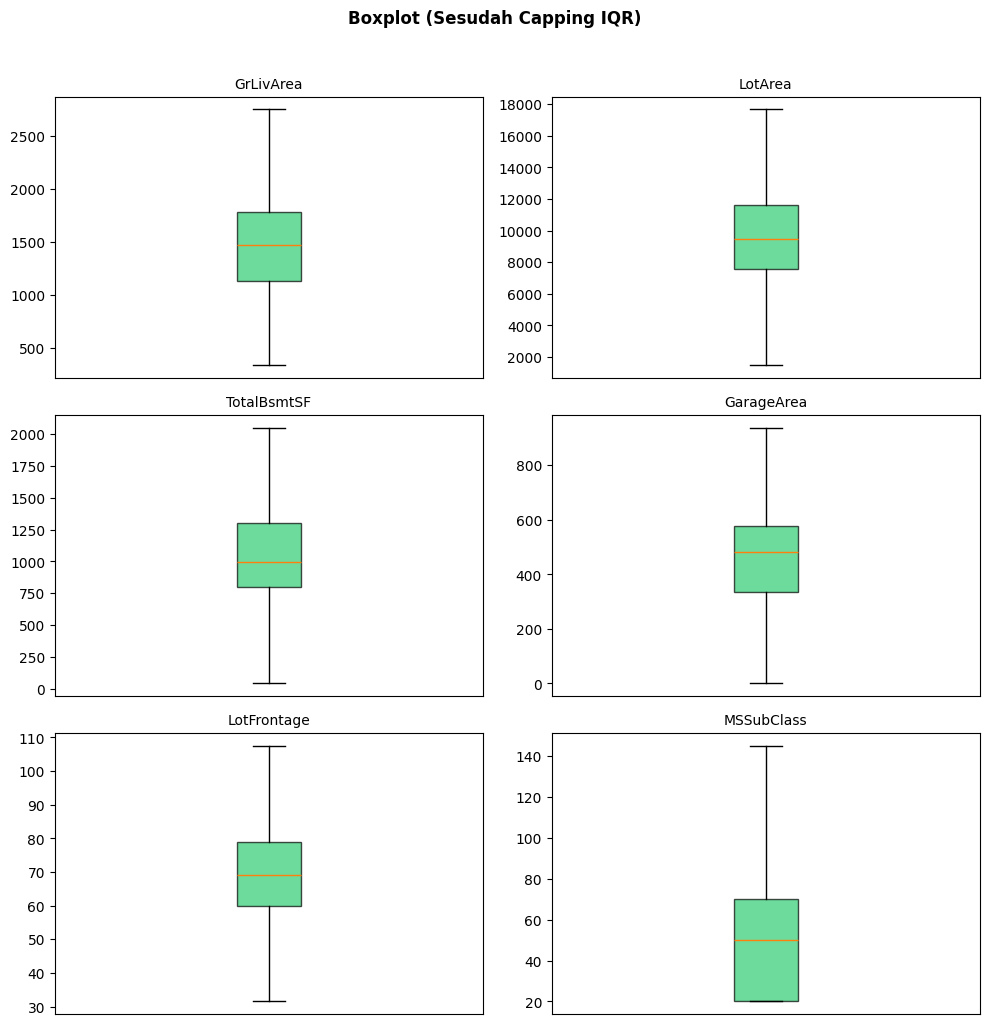

In [9]:
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes_flat = axes.flatten()
for i, col in enumerate(sample_cols):
    axes_flat[i].boxplot(df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor='#2ecc71', alpha=0.7),)
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].set_xticks([])
plt.suptitle('Boxplot (Sesudah Capping IQR)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Id', 'SalePrice'])
y = df['SalePrice']

X_encoded = pd.get_dummies(X, drop_first=True)
print('Shape setelah One-Hot Encoding:', X_encoded.shape)

Shape setelah One-Hot Encoding: (1460, 233)


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print('Mean rata-rata fitur (seharusnya ~0):', X_scaled_df.mean().mean().round(4))
print('Std rata-rata fitur  (seharusnya ~1):', X_scaled_df.std().mean().round(4))

Mean rata-rata fitur (seharusnya ~0): 0.0
Std rata-rata fitur  (seharusnya ~1): 0.9617


In [12]:
corr_matrix = X_scaled_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f'Kolom dihapus (korelasi > 0.95): {len(to_drop_corr)}')
print(to_drop_corr)

X_final = X_scaled_df.drop(columns=to_drop_corr)
print('Shape setelah seleksi korelasi:', X_final.shape)

Kolom dihapus (korelasi > 0.95): 5
['Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'SaleCondition_Partial']
Shape setelah seleksi korelasi: (1460, 228)


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_final)

print(f'Jumlah komponen PCA: {X_pca.shape[1]}')
print(f'Shape dataset akhir: {X_pca.shape}')

Jumlah komponen PCA: 150
Shape dataset akhir: (1460, 150)


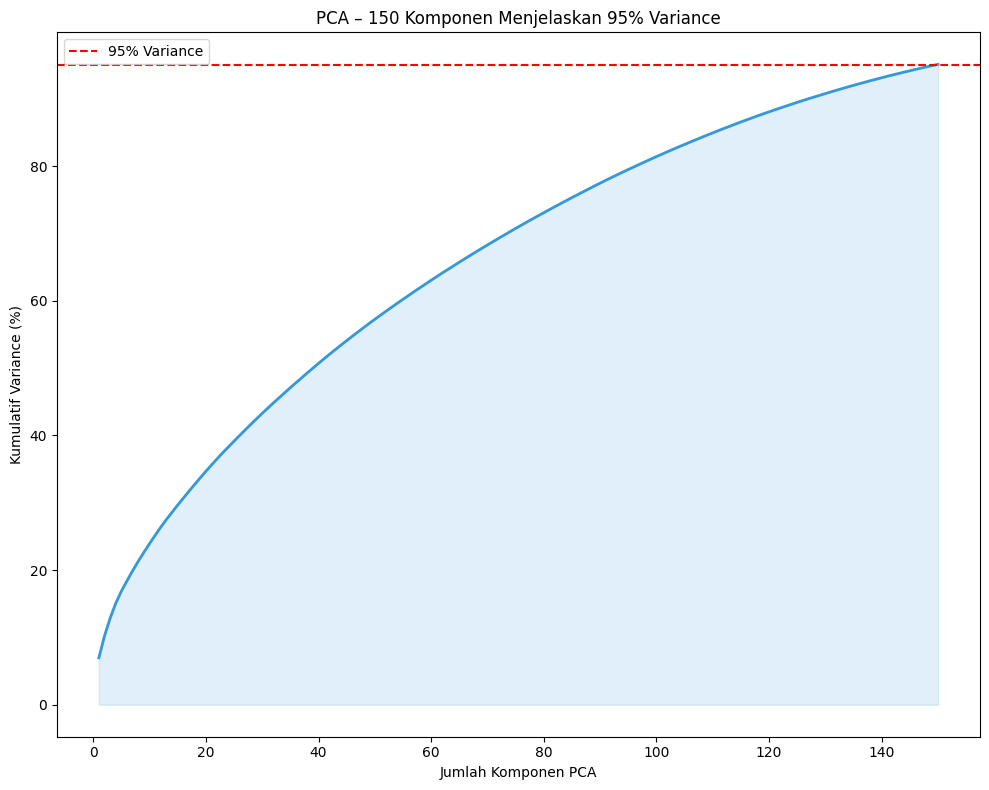

In [14]:
cumsum = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 8))
plt.plot(range(1, len(cumsum)+1), cumsum, color='#3498db', lw=2)
plt.fill_between(range(1, len(cumsum)+1), cumsum, alpha=0.15, color='#3498db')
plt.axhline(95, color='red', linestyle='--', label='95% Variance')
plt.xlabel('Jumlah Komponen PCA')
plt.ylabel('Kumulatif Variance (%)')
plt.title(f'PCA – {X_pca.shape[1]} Komponen Menjelaskan 95% Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
summary = pd.DataFrame([
    {'Tahap': 'Dataset Awal',               'Shape': '1460 × 81'},
    {'Tahap': 'Hapus Kolom >50% Missing',   'Shape': '1460 × 76'},
    {'Tahap': 'Imputasi Nilai Hilang',       'Shape': '1460 × 76'},
    {'Tahap': 'Capping Outlier (IQR)',       'Shape': '1460 × 76'},
    {'Tahap': 'One-Hot Encoding',            'Shape': f'1460 × {X_encoded.shape[1]}'},
    {'Tahap': 'Standarisasi Z-score',        'Shape': '1460 × 233'},
    {'Tahap': 'Hapus Korelasi >0.95',        'Shape': f'1460 × {X_final.shape[1]}'},
    {'Tahap': 'PCA (95% variance)',           'Shape': f'1460 × {X_pca.shape[1]}'},
])
summary

,Tahap,Shape
0,Dataset Awal,1460 × 81
1,Hapus Kolom >50% Missing,1460 × 76
2,Imputasi Nilai Hilang,1460 × 76
3,Capping Outlier (IQR),1460 × 76
4,One-Hot Encoding,1460 × 233
5,Standarisasi Z-score,1460 × 233
6,Hapus Korelasi >0.95,1460 × 228
7,PCA (95% variance),1460 × 150


In [16]:
df.to_csv('train_clean.csv', index=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (1460, 76)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450.0,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600.0,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250.0,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550.0,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260.0,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
